#Agenda:
- kaggle Dataset Mnist dataset
- Train on ANN
- improve

Steps to use GPU:

* Write device Agnostic Code
* Move Model to GPU
* Modify the Training loop by moving Data to GPU
* Moving the Data to GPU in Evaluation Loop

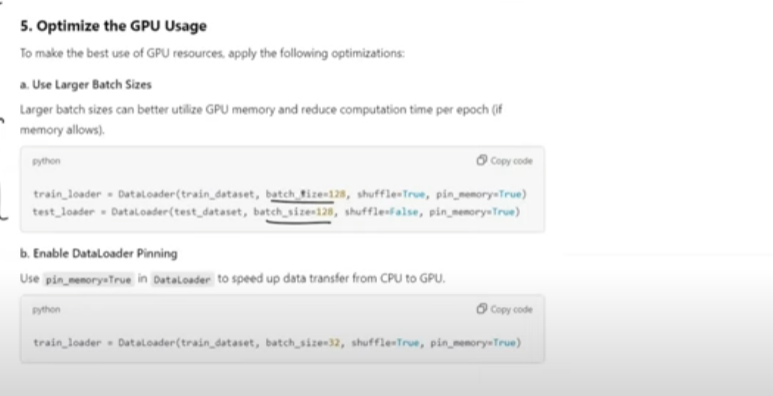

In [25]:
#importing some necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader

In [4]:
#device Agnostic code
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
#random seed for reproducibility
torch.manual_seed(42)

In [9]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
 55% 38.0M/68.8M [00:00<00:00, 181MB/s] 
100% 68.8M/68.8M [00:00<00:00, 207MB/s]


In [10]:
!unzip fashionmnist.zip

Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


In [11]:
df=pd.read_csv('/content/fashion-mnist_train.csv')

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0.0,7.0,0.0,50.0,205.0,196.0,213.0,165.0,0.0,0.0
1,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1,0,0,0,...,142.0,142.0,142.0,21.0,0.0,3.0,0.0,0.0,0.0,0.0
3,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8,0,0,0,0,0,0,0,0,0,...,213.0,203.0,174.0,151.0,188.0,10.0,0.0,0.0,0.0,0.0


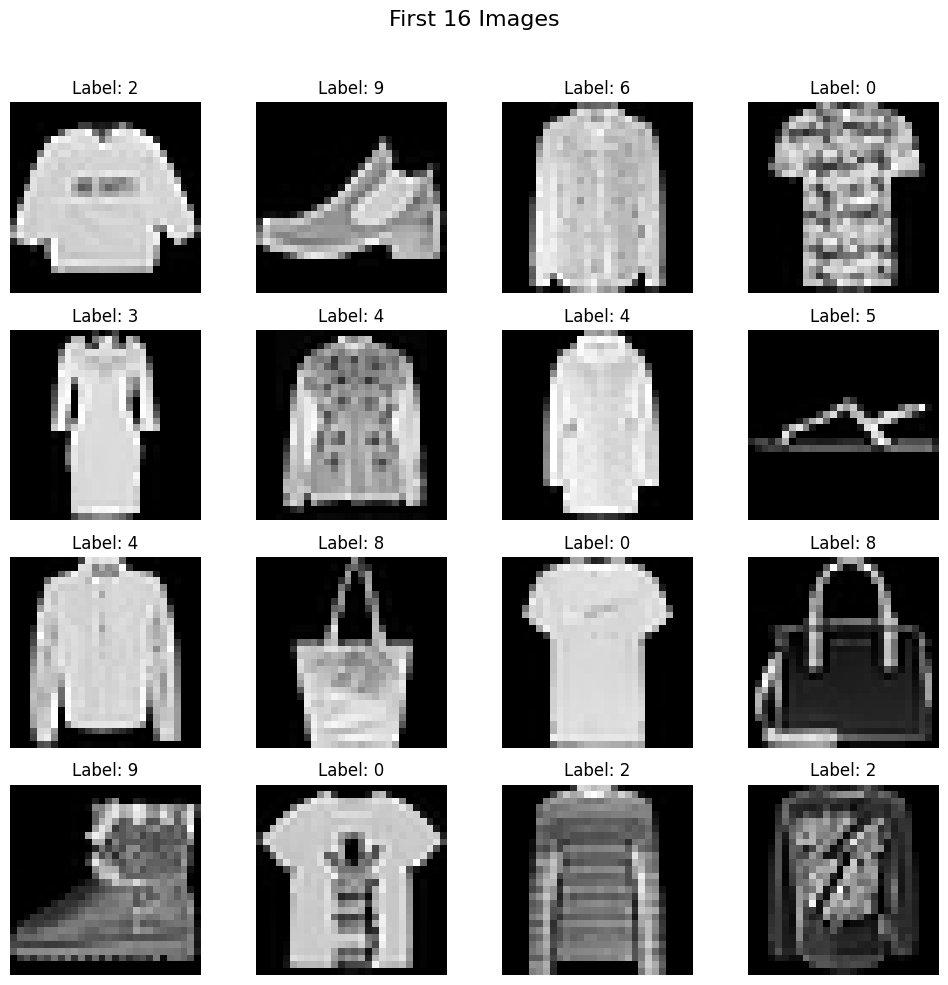

In [12]:
# Create a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)  # Set a title for the whole figure

# Loop through the first 16 images and plot them
for i, ax in enumerate(axes.flat):  # Iterate over all 16 subplot axes
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Extract pixel values and reshape to 28x28
    ax.imshow(img, cmap='gray')  # Display the image in grayscale
    ax.axis('off')  # Remove the axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Display the label

# Adjust layout to fit the title properly
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()  # Display the plot

In [13]:
#generate x and y
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [14]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [15]:
#scaling our dataset
x_train=x_train/255.0
x_test=x_test/255.0

In [16]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [17]:
x_train.shape

(48000, 784)

In [18]:
#custom dataset
class CustomDataset(Dataset):

  def __init__(self,feature,labels):

    self.feature=torch.tensor(feature,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.feature)

  def __getitem__(self,index):

    return self.feature[index],self.labels[index]

In [19]:
train_dataset=CustomDataset(x_train,y_train)

In [20]:
test_dataset=CustomDataset(x_test,y_test)

In [21]:
len(train_dataset)

48000

In [22]:
len(test_dataset)

12000

In [23]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [24]:
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [26]:
#create ANN Model

class MyNN(nn.Module):

  def __init__(self,input_size):
    super().__init__()
    self.network=nn.Sequential(
        nn.Linear(in_features=input_size,out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128,out_features=64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.network(x)

In [30]:
#set epochs nad learning rate
epochs=15
lr=0.01

In [28]:
#instance of model
model=MyNN(x_train.shape[1])
model=model.to(device)
#loss functions
loss=nn.CrossEntropyLoss()

#optimizer
optimizer=optim.SGD(
    params=model.parameters(),
    lr=lr
)

In [31]:
#Training loop
for epoch in range(epochs):
  each_epoch_loss=0 #to calcluate loss of each epoch
  for batch_feature,batch_label in train_loader:
    #moving data to gpu
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    #forward pass
    y_pred=model(batch_feature)
    #calculate loss
    train_loss=loss(y_pred,batch_label)
    #backpropagation
    optimizer.zero_grad()
    train_loss.backward()
    #update parameters
    optimizer.step()

    each_epoch_loss+=train_loss.item()
  avg_loss=each_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch} | Loss: {avg_loss}")


Epoch: 0 | Loss: 0.409029540648063
Epoch: 1 | Loss: 0.39882580849031607
Epoch: 2 | Loss: 0.3908455869406462
Epoch: 3 | Loss: 0.3806435105204582
Epoch: 4 | Loss: 0.37435664622982345
Epoch: 5 | Loss: 0.3676710741817951
Epoch: 6 | Loss: 0.3620927956700325
Epoch: 7 | Loss: 0.3549170082087318
Epoch: 8 | Loss: 0.34895279042919475
Epoch: 9 | Loss: 0.3429446270863215
Epoch: 10 | Loss: 0.3369019116163254
Epoch: 11 | Loss: 0.3306294097652038
Epoch: 12 | Loss: 0.32650075027594966
Epoch: 13 | Loss: 0.32238364341855047
Epoch: 14 | Loss: 0.3161189106876651


In [32]:
#Model Evaluation
model.eval()

MyNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [34]:
total=0
correct=0

with torch.no_grad():
  for batch_feature,batch_label in test_loader:
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    y_pred=model(batch_feature)
    _,predict=torch.max(y_pred,1)
    total+=batch_label.shape[0]
    correct+=(predict==batch_label).sum().item()
print(f"{(correct/total)*100}%")


87.1%
